<a href="https://colab.research.google.com/github/Harshilkumarghori/localrepo/blob/main/Few_shot_Learning_Superclassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# 1. Load dataset
data = load_iris()
X, y = data.data, data.target

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Simulate domain shift: Add noise to test set
rng = np.random.RandomState(42)
X_test_shifted = X_test + rng.normal(0, 0.5, X_test.shape)

In [ ]:
# 2. Train two base classifiers
clf1 = SVC(probability=True, random_state=42)
clf2 = RandomForestClassifier(random_state=42)
clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)

# Predictions from base models
pred1 = clf1.predict(X_test_shifted)
pred2 = clf2.predict(X_test_shifted)

acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)

# Simple Ensemble (average probabilities)
proba1 = clf1.predict_proba(X_test_shifted)
proba2 = clf2.predict_proba(X_test_shifted)
ensemble_proba = (proba1 + proba2) / 2
ensemble_pred = np.argmax(ensemble_proba, axis=1)
ensemble_acc = accuracy_score(y_test, ensemble_pred)

In [ ]:
# 3. Few-shot samples from shifted domain
few_shot_size = 15
idx = rng.choice(len(X_test_shifted), few_shot_size, replace=False)
X_few, y_few = X_test_shifted[idx], y_test[idx]

# Create meta-features: outputs from base classifiers on few-shot samples
meta_features_few = np.column_stack([
    clf1.predict_proba(X_few),
    clf2.predict_proba(X_few)
])

# Train superclassifier on few-shot samples
super_clf = LogisticRegression(max_iter=500)
super_clf.fit(meta_features_few, y_few)

LogisticRegression(max_iter=500)

In [ ]:

# Apply superclassifier on full test set
meta_features_test = np.column_stack([
    clf1.predict_proba(X_test_shifted),
    clf2.predict_proba(X_test_shifted)
])
super_pred = super_clf.predict(meta_features_test)
super_acc = accuracy_score(y_test, super_pred)

# Print results
print("Base Model 1 (SVM):", round(acc1 * 100, 2), "%")
print("Base Model 2 (RF):", round(acc2 * 100, 2), "%")
print("Ensemble:", round(ensemble_acc * 100, 2), "%")
print("Superclassifier:", round(super_acc * 100, 2), "%")


Base Model 1 (SVM): 90.0 %
Base Model 2 (RF): 86.67 %
Ensemble: 91.67 %
Superclassifier: 91.67 %


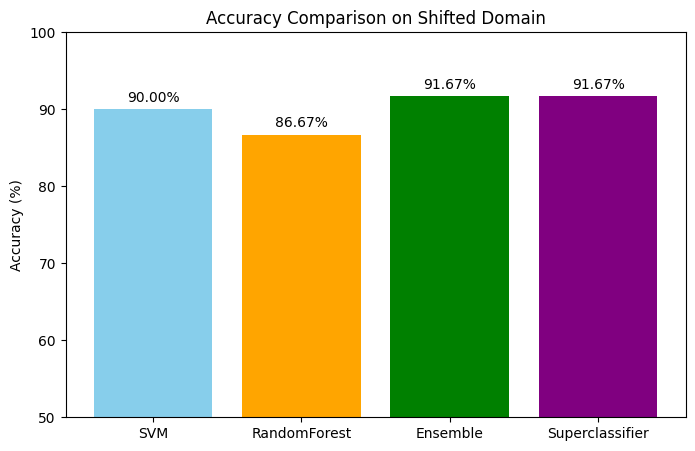

In [ ]:

# Plot comparison
models = ['SVM', 'RandomForest', 'Ensemble', 'Superclassifier']
accuracies = [acc1 * 100, acc2 * 100, ensemble_acc * 100, super_acc * 100]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'orange', 'green', 'purple'])
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Comparison on Shifted Domain')
plt.ylim(50, 100)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha='center')
plt.show()